In [29]:
import warnings
warnings.filterwarnings("ignore")  # suppress sklearn warnings for cleaner output


import json
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

pd.set_option("display.max_columns", None)  # show all columns in DataFrame outputs
sns.set_theme(style="whitegrid")

In [19]:
df = pd.read_csv("../data/synthetic_billing.csv")
print(df.shape)
display(df.head(20))

display(df.isnull().sum().sort_values(ascending=False).head(10))

display(df['claim_status'].value_counts(normalize=True).rename("pct"))

(20000, 16)


,patient_id,patient_age,insurance_type,procedure_cpt_code,diagnosis_code,billed_amount,days_since_last_claim,num_prior_claims,prior_denial_rate,is_code_mismatch,is_high_cost_procedure,is_frequent_claimer,is_recent_repeat_claim,claim_status,anomaly_label,date
0,1,19,Private,99213,M79.3,144.33,999,0,0.000,0,0,0,0,1,0,2026-02-01
1,1,19,Private,97110,M25.5,127.01,115,1,1.000,0,0,0,0,0,1,2026-05-27
2,2,70,Private,99214,R51,151.39,999,0,0.000,0,0,0,0,0,0,2025-09-15
3,1,19,Private,85025,Z00.00,66.42,93,2,0.500,0,0,0,0,0,1,2026-08-28
4,2,70,Private,99281,E11.9,186.26,94,1,0.000,1,0,0,0,1,0,2025-12-18
5,1,19,Private,80053,R10.9,101.82,98,3,0.333,0,0,0,0,0,0,2026-12-04
6,2,70,Private,99213,N39.0,101.02,81,2,0.500,0,0,0,0,1,0,2026-03-09
7,2,70,Private,96372,M79.3,58.16,37,3,0.667,0,0,0,0,1,0,2026-04-15
8,2,70,Private,85025,Z00.00,51.21,131,4,0.750,0,0,0,0,0,0,2026-08-24
9,1,19,Private,99213,J02.9,121.53,120,4,0.250,0,0,0,0,0,0,2027-04-03


patient_id               0
patient_age              0
insurance_type           0
procedure_cpt_code       0
diagnosis_code           0
billed_amount            0
days_since_last_claim    0
num_prior_claims         0
prior_denial_rate        0
is_code_mismatch         0
dtype: int64

claim_status
0    0.6192
1    0.3808
Name: pct, dtype: float64

In [20]:
print("Denial Rate by Insurance")
display(df.groupby("insurance_type")["claim_status"].mean().sort_values(ascending=False).round(3))

display(df.columns)

for col in ['is_code_mismatch', 'is_high_cost_procedure', 'is_frequent_claimer', 'is_recent_repeat_claim']:
    if col in df.columns:
        print(f"Denial rate by {col}: ")
        display(df.groupby(col)['claim_status'].mean())

Denial Rate by Insurance


insurance_type
Self-pay    0.596
Medicaid    0.380
Medicare    0.303
Private     0.248
Name: claim_status, dtype: float64

Index(['patient_id', 'patient_age', 'insurance_type', 'procedure_cpt_code',
       'diagnosis_code', 'billed_amount', 'days_since_last_claim',
       'num_prior_claims', 'prior_denial_rate', 'is_code_mismatch',
       'is_high_cost_procedure', 'is_frequent_claimer',
       'is_recent_repeat_claim', 'claim_status', 'anomaly_label', 'date'],
      dtype='object')

Denial rate by is_code_mismatch: 


is_code_mismatch
0    0.338240
1    0.673092
Name: claim_status, dtype: float64

...

is_high_cost_procedure
0    0.374427
1    0.535354
Name: claim_status, dtype: float64

Denial rate by is_frequent_claimer: 


is_frequent_claimer
0    0.367531
1    0.645702
Name: claim_status, dtype: float64

Denial rate by is_recent_repeat_claim: 


is_recent_repeat_claim
0    0.378449
1    0.472112
Name: claim_status, dtype: float64

In [26]:
target = 'claim_status'
print(df.columns)
print(df.shape)
drop_cols = ['patient_id', 'date', 'anomaly_label','claim_status']

X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns]) # drop non-feature columns if exist
y = df[target].astype(int)  # ensure target is numeric

categorical_cols = [c for c in ['insurance_type', 'procedure_cpt_code', 'diagnosis_code'] if c in X_raw.columns]
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)  # one-hot encode categorical features

print("X shape:", X.columns)


Index(['patient_id', 'patient_age', 'insurance_type', 'procedure_cpt_code',
       'diagnosis_code', 'billed_amount', 'days_since_last_claim',
       'num_prior_claims', 'prior_denial_rate', 'is_code_mismatch',
       'is_high_cost_procedure', 'is_frequent_claimer',
       'is_recent_repeat_claim', 'claim_status', 'anomaly_label', 'date'],
      dtype='object')
(20000, 16)
X shape: Index(['patient_age', 'billed_amount', 'days_since_last_claim',
       'num_prior_claims', 'prior_denial_rate', 'is_code_mismatch',
       'is_high_cost_procedure', 'is_frequent_claimer',
       'is_recent_repeat_claim', 'insurance_type_Medicare',
       'insurance_type_Private', 'insurance_type_Self-pay',
       'procedure_cpt_code_70450', 'procedure_cpt_code_71020',
       'procedure_cpt_code_73610', 'procedure_cpt_code_80053',
       'procedure_cpt_code_80061', 'procedure_cpt_code_82947',
       'procedure_cpt_code_85025', 'procedure_cpt_code_87070',
       'procedure_cpt_code_93000', 'procedure_cpt_code_

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Tst: {X_test_s.shape}")


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    
    results.append(metrics)
    trained[name] = (model, y_pred, y_proba)
    
comparison = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison.style.format({c: "{:.4f}" for c in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]}))

Train: (16000, 45), Tst: (4000, 45)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.6957,0.6364,0.4688,0.5399,0.7260
1,Gradient Boosting,0.6955,0.6325,0.4780,0.5445,0.7233
2,Random Forest,0.6817,0.5992,0.4957,0.5426,0.7022


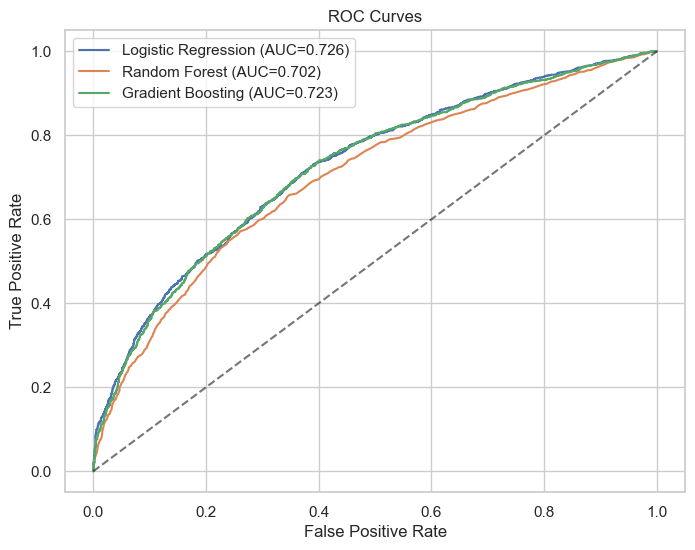

In [32]:
plt.figure(figsize=(8,6))
for name, (_, _, y_proba) in trained.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    
plt.plot([0,1],[0,1],"k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [34]:
best_name = comparison.iloc[0]["Model"]
best_model, _, best_proba = trained[best_name]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []

for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall': recall_score(y_test, pred_t, zero_division=0),
        'F1': f1_score(y_test, pred_t, zero_division=0)
    })
    
th_df = pd.DataFrame(rows)
display(th_df.style.format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"}))

,threshold,Precision,Recall,F1
0,0.300000,0.5305,0.7367,0.6168
1,0.400000,0.5639,0.6231,0.5920
2,0.500000,0.6364,0.4688,0.5399
3,0.600000,0.7051,0.3454,0.4636
4,0.700000,0.7479,0.2357,0.3585


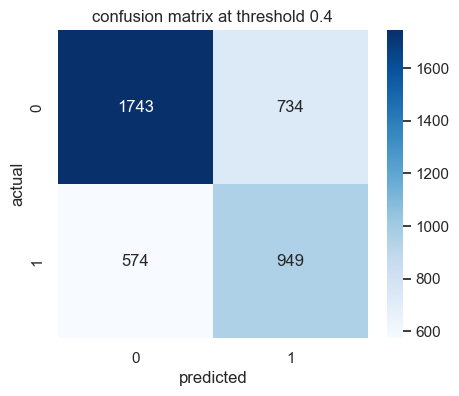

              precision    recall  f1-score   support

           0     0.7523    0.7037    0.7272      2477
           1     0.5639    0.6231    0.5920      1523

    accuracy                         0.6730      4000
   macro avg     0.6581    0.6634    0.6596      4000
weighted avg     0.6805    0.6730    0.6757      4000



In [37]:
chosen_threshold = 0.40

pred = (best_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"confusion matrix at threshold {chosen_threshold}")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

print(classification_report(y_test, pred, digits=4))

,feature,importance
5,is_code_mismatch,0.538044
4,prior_denial_rate,0.466580
11,insurance_type_Self-pay,0.376287
1,billed_amount,0.363347
7,is_frequent_claimer,0.260096
10,insurance_type_Private,0.225391
6,is_high_cost_procedure,0.160399
28,procedure_cpt_code_99283,0.150675
30,procedure_cpt_code_99285,0.142510
24,procedure_cpt_code_99214,0.106564


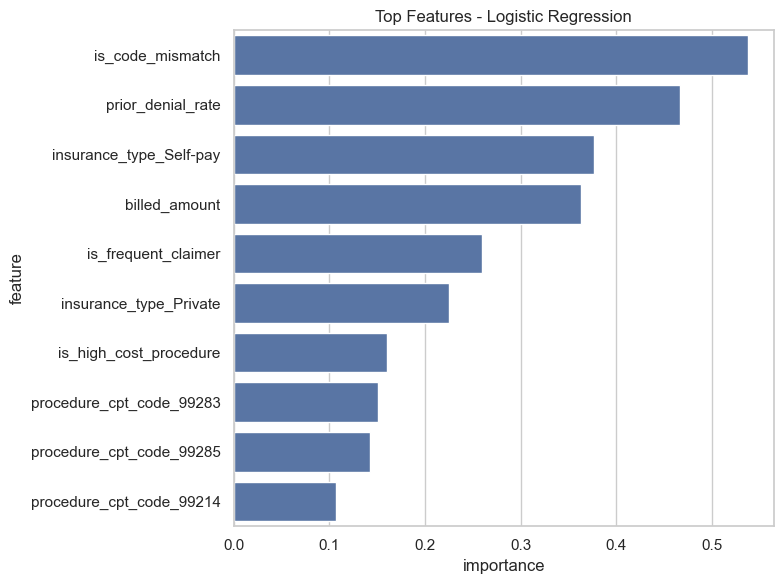

In [42]:
feature_names = X.columns.tolist()
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else: 
    importances = np.abs(best_model.coef_[0])  # placeholder if model doesn't have feature_importances_
f1 = pd.DataFrame({"feature": feature_names, "importance": importances})
f1 = f1.sort_values("importance", ascending=False).head(10)
display(f1)

plt.figure(figsize=(8,6))
sns.barplot(data=f1, y="feature", x="importance")
plt.title(f"Top Features - {best_name}")
plt.tight_layout()
plt.show()

In [44]:
save_dir = Path("ml/models/saved")
save_dir.mkdir(parents=True, exist_ok=True)

# Refit on train set already done above; use best_model directly.
joblib.dump(best_model, save_dir / "denial_model.pkl")
joblib.dump(scaler, save_dir / "denial_model_scaler.pkl")
joblib.dump(feature_names, save_dir / "denial_model_features.pkl")

best_auc = float(comparison.iloc[0]["ROC-AUC"])
top_features = f1["feature"].head(10).tolist()

metadata = {
    "model_type": best_name,
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_size": int(len(df)),
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "numeric_features": int(len(feature_names)),
    "metrics": {
        "accuracy": float(comparison.iloc[0]["Accuracy"]),
        "precision": float(comparison.iloc[0]["Precision"]),
        "recall": float(comparison.iloc[0]["Recall"]),
        "f1_score": float(comparison.iloc[0]["F1"]),
        "roc_auc": best_auc,
    },
    "top_features": top_features,
    "all_model_results": comparison.to_dict(orient="records"),
    "chosen_threshold": 0.40,
}

with open(save_dir / "denial_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved artifacts to", save_dir)
print("Best model:", best_name, "| AUC:", round(best_auc, 4))

Saved artifacts to ml\models\saved
Best model: Logistic Regression | AUC: 0.726


In [45]:
target_auc = 0.80
if best_auc >= target_auc:
    print(f"PASS: AUC {best_auc:.4f} >= {target_auc:.2f}")
else:
    print(f"FAIL: AUC {best_auc:.4f} < {target_auc:.2f}")
    print("Next actions: strengthen signal rules, reduce noise, inspect feature drift, retune model hyperparameters.")

FAIL: AUC 0.7260 < 0.80
Next actions: strengthen signal rules, reduce noise, inspect feature drift, retune model hyperparameters.
